# Stringer et al. 2019 — Quick Tour

Two-photon calcium imaging of ~10k neurons in mouse visual cortex in response to 2,800 natural images.

**32 sessions** across 7 mice and 7 stimulus types: `natimg2800`, `natimg2800_white`, `natimg2800_8D`, `natimg2800_4D`, `natimg2800_small`, `ori32`, `natimg32`.

In [ ]:
import os, sys
external_path = os.getcwd()
sys.path.append(external_path)

import matplotlib.pyplot as plt
from stringer2019 import (
    StringerRegistry,
    plot_rastermap,
    plot_stim_responses,
    plot_tuning_curves,
)

%matplotlib inline

c:\Users\Andrew\Documents\GitHub\vrAnalysis\notebooks\external


## Registry — discover what's available

In [8]:
reg = StringerRegistry()
print(reg)
reg.available()

StringerRegistry(32 sessions, 7 mice, 7 stimulus types)
mouse_name      date          stimset                 mouse_type          nplanes 
--------------  ------------  ----------------------  ------------------  --------
M160825_MP027   2016-12-14    natimg2800              EMX_G6s             12      
M161025_MP030   2017-05-29    natimg2800              TETO_G6s            12      
M170604_MP031   2017-06-28    natimg2800              GADxtdTomato        12      
M170714_MP032   2017-08-07    natimg2800              GADxtdTomato        12      
M170714_MP032   2017-09-14    natimg2800              GADxtdTomato        12      
M170717_MP033   2017-08-20    natimg2800              tetO                12      
M170717_MP034   2017-09-11    natimg2800              tetO                12      
M170714_MP032   2017-09-11    natimg2800_white        GADxtdTomato        12      
M170714_MP032   2017-09-12    natimg2800_white        GADxtdTomato        12      
M170717_MP034   2017-09-14    n

In [10]:
# Filter by stimulus type or mouse
reg.list(stimset="ori32")

[RecordingInfo('M160825_MP027', '2016-12-15', stimset='ori32', nplanes=12),
 RecordingInfo('M170604_MP031', '2017-06-26', stimset='ori32', nplanes=12),
 RecordingInfo('M170714_MP032', '2017-08-02', stimset='ori32', nplanes=12),
 RecordingInfo('M170717_MP033', '2017-08-17', stimset='ori32', nplanes=12)]

## Load an experiment

Data loads lazily — nothing is read from disk until you access a property.

In [11]:
exp = reg.get("M160825_MP027", "2016-12-15")
print(exp)
print(f"resp:  {exp.resp.shape}   # (n_presentations, n_cells)")
print(f"spont: {exp.spont.shape}  # (n_frames, n_cells)")
print(f"istim: {exp.istim.shape}, gray_screen_id={exp.gray_screen_id}")
print(f"med:   {exp.med.shape}    # (n_cells, 3) — [y, x, plane]")

StringerExperiment('M160825_MP027', '2016-12-15', stimset='ori32', [not loaded])
resp:  (2304, 11302)   # (n_presentations, n_cells)
spont: (256, 11302)  # (n_frames, n_cells)
istim: (2304,), gray_screen_id=33
med:   (11302, 3)    # (n_cells, 3) — [y, x, plane]


In [14]:
# Average over repeated presentations → (n_unique_stim, n_cells)
mean_resp = exp.mean_responses()
print(f"mean_responses: {mean_resp.shape}")

mean_responses: (32, 11302)


## Rastermap of spontaneous activity

2026-04-01 12:34:16,742 [INFO] normalizing data across axis=1
2026-04-01 12:34:16,754 [INFO] projecting out mean along axis=0
2026-04-01 12:34:16,768 [INFO] data normalized, 0.03sec
2026-04-01 12:34:16,769 [INFO] sorting activity: 11302 valid samples by 256 timepoints
2026-04-01 12:34:17,085 [INFO] n_PCs = 200 computed, 0.34sec
2026-04-01 12:34:18,143 [INFO] 100 clusters computed, time 1.40sec
2026-04-01 12:34:25,069 [INFO] clusters sorted, time 8.33sec
2026-04-01 12:34:25,399 [INFO] clusters upsampled, time 8.66sec
2026-04-01 12:34:25,408 [INFO] rastermap complete, time 8.67sec


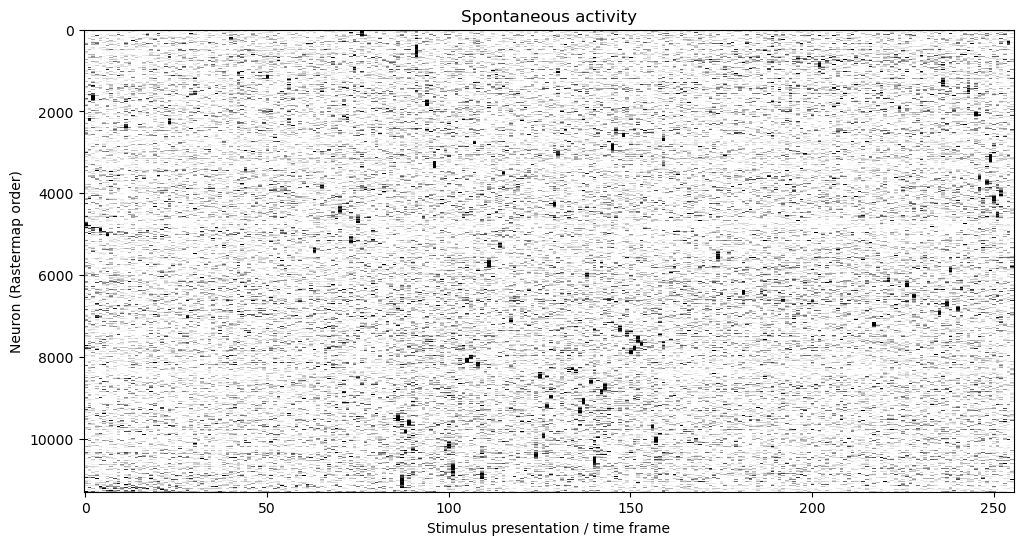

isort shape: (11302,)  ← neuron sort order


In [15]:
fig, ax, model = plot_rastermap(exp.spont, title="Spontaneous activity")
plt.show()
print(f"isort shape: {model.isort.shape}  ← neuron sort order")

2026-04-01 12:34:45,980 [INFO] normalizing data across axis=1
2026-04-01 12:34:45,982 [INFO] projecting out mean along axis=0
2026-04-01 12:34:45,985 [INFO] data normalized, 0.01sec
2026-04-01 12:34:45,985 [INFO] sorting activity: 11302 valid samples by 32 timepoints
2026-04-01 12:34:46,010 [INFO] n_PCs = 32 computed, 0.03sec
2026-04-01 12:34:46,869 [INFO] 100 clusters computed, time 0.89sec
2026-04-01 12:34:54,375 [INFO] clusters sorted, time 8.40sec
2026-04-01 12:34:54,579 [INFO] clusters upsampled, time 8.60sec
2026-04-01 12:34:54,584 [INFO] rastermap complete, time 8.60sec


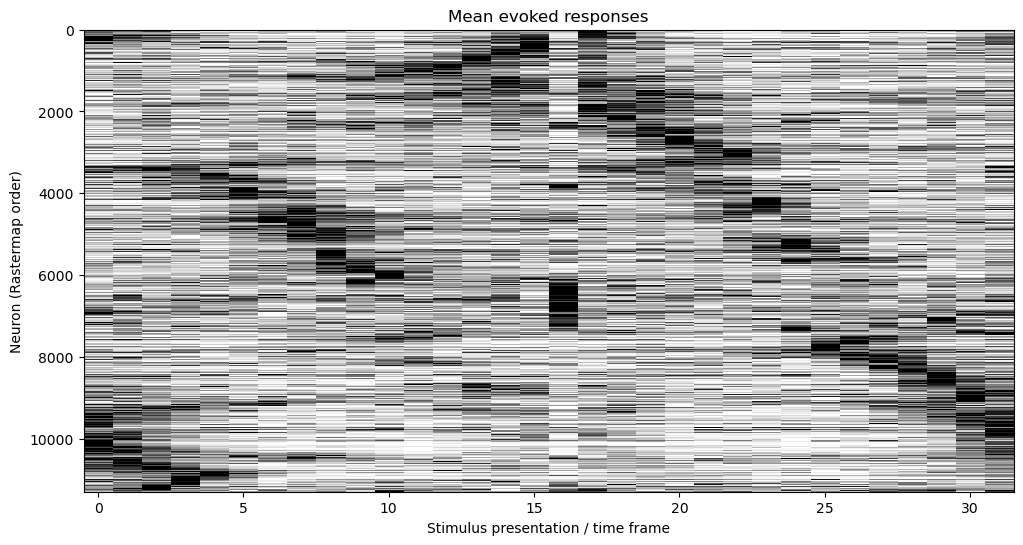

In [16]:
# Same thing on evoked responses (mean over repeats, sorted by rastermap)
fig, ax, model_resp = plot_rastermap(mean_resp, title="Mean evoked responses")
plt.show()

## Stimulus images + population responses

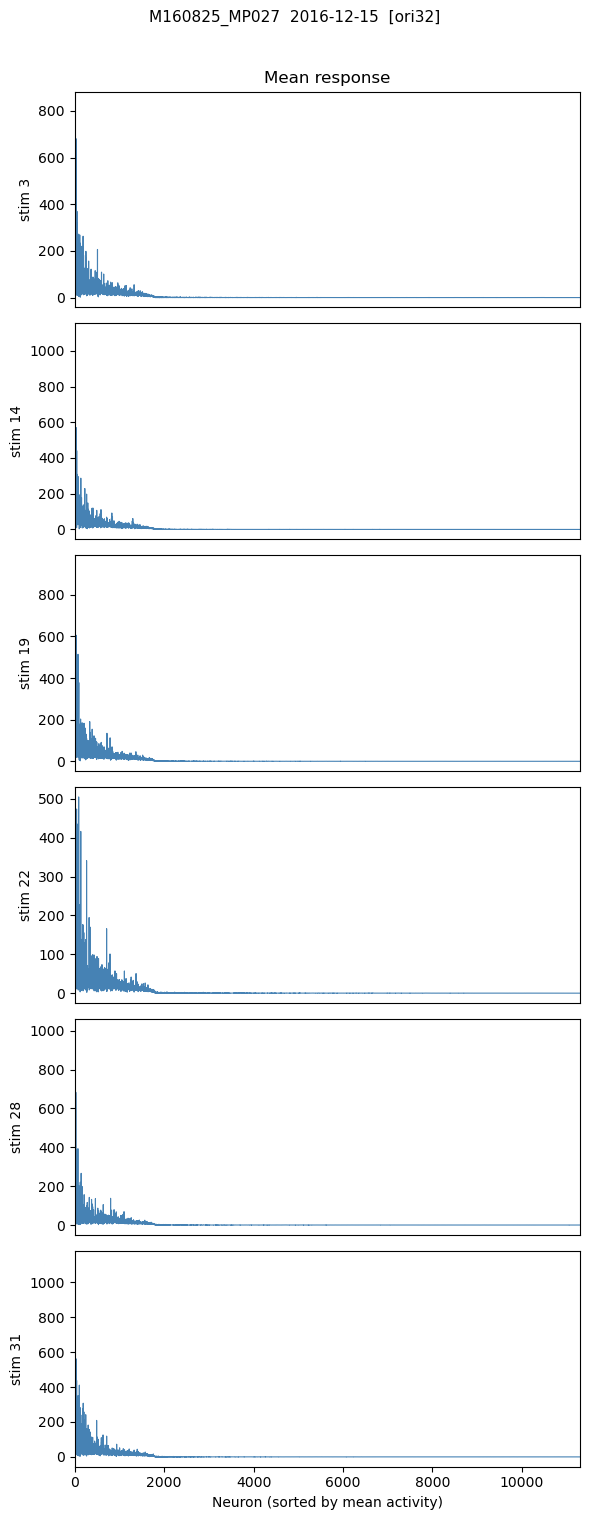

In [17]:
fig = plot_stim_responses(exp, n_stim=6, seed=42)
plt.show()

## Orientation tuning (ori32 session)

In [ ]:
ori_exp = reg.get("M160825_MP027", "2016-12-15")
print(ori_exp)
print(f"ori directions: {ori_exp.ori[:-1]}")  # last entry is gray screen
print(f"reps shape: {ori_exp.reps.shape}  # (n_unique+1, n_cells, 2_repeats)")

StringerExperiment('M160825_MP027', '2016-12-15', stimset='ori32', [not loaded])
ori directions: [  0  11  23  34  45  56  68  79  90 101 113 124 135 146 158 169 180 191
 203 214 225 236 248 259 270 281 293 304 315 326 338 349]
reps shape: (33, 11302, 2)  # (n_unique+1, n_cells, 2_repeats)


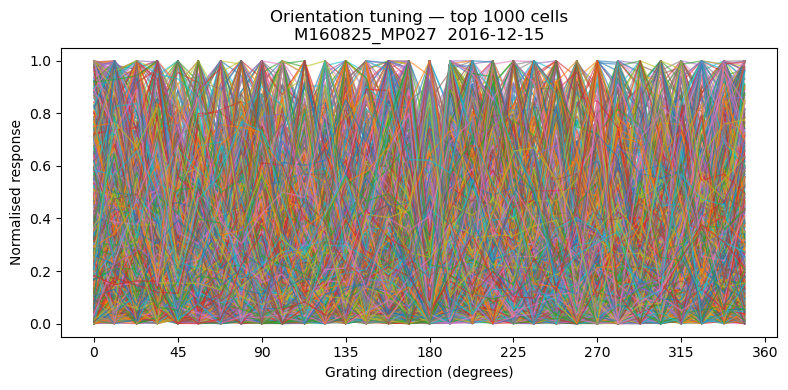

In [25]:
fig, ax = plot_tuning_curves(ori_exp, n_cells=1000)
plt.show()

## Extras — cell positions & interneuron labels

Some mice (e.g. `GADxtdTomato`, `GADxtdTomato`) have tdTomato labeling for GAD+ interneurons.

In [ ]:
# Load a GADxtdTomato mouse — has redcell / redprob
exp_gad = reg.get("M170604_MP031", "2017-06-28")
print(f"redcell available: {exp_gad.redcell is not None}")
print(f"redprob available: {exp_gad.redprob is not None}")

if exp_gad.redcell is not None:
    n_inh = exp_gad.redcell.sum()
    print(f"Interneurons (tdTomato+): {n_inh} / {exp_gad.n_cells}")

In [ ]:
# Cell positions: med is (n_cells, 3) → [y, x, plane]
import numpy as np

med = exp.med
fig, ax = plt.subplots(figsize=(7, 4))
sc = ax.scatter(med[:, 1], med[:, 0], c=med[:, 2], s=0.5, cmap="tab20", alpha=0.4)
plt.colorbar(sc, ax=ax, label="plane")
ax.set_xlabel("x (pixels)")
ax.set_ylabel("y (pixels)")
ax.set_title(f"Cell positions — {exp.mouse_name} {exp.date} ({exp.n_cells} cells)")
ax.invert_yaxis()
plt.show()